In [390]:
import jax.numpy as jnp
from jax.scipy.linalg import solve
import matplotlib.pyplot as plt
from scipy.interpolate import RegularGridInterpolator 
import numpy as np  

# Implicit method (4.2.5) 

In [391]:
# ---- Parameters ----
V_MAX = 201
M = 1000
x_max = 3
x_min = -3

option_type = "call"  # "put" or "call"
T = 1
K = 40

r = 0.05
delta = 0.02
sigma = 0.2

In [392]:
# ---- Grid setup ----
x = jnp.linspace(x_min, x_max, V_MAX)
x_interior = x[1:-1]  # length V_MAX - 2

delta_x = (x_max - x_min) / (V_MAX - 1)
tau_max = 0.5 * sigma**2 * T
delta_tau = tau_max / (M - 1)
lamb = delta_tau / (delta_x ** 2)

In [393]:
# ---- Initial condition w(x, 0) ----
q_delta = 2 * (r - delta) / (sigma ** 2)
a = -0.5 * (q_delta - 1 if option_type == "call" else q_delta + 1)
if option_type == "call":
    initial = jnp.maximum(jnp.exp(x_interior) - 1, 0)
else:
    initial = jnp.maximum(1 - jnp.exp(x_interior), 0)

w = jnp.zeros((V_MAX - 2, M))
w = w.at[:, 0].set(initial * jnp.exp(a * x_interior))


In [394]:
# ---- Construct A matrix - equation (4.18) ----
diag_main = (1 + 2 * lamb) * jnp.ones(V_MAX - 2)
diag_off = -lamb * jnp.ones(V_MAX - 3)
A = jnp.diag(diag_main) + jnp.diag(diag_off, 1) + jnp.diag(diag_off, -1)

In [395]:
# ---- Time stepping - equation (4.19) ----
def step_fn(w_nu):
    return solve(A, w_nu, assume_a='pos') #solve the linear system of equations

for nu in range(M - 1):
    w = w.at[:, nu + 1].set(step_fn(w[:, nu]))

In [396]:
# ---- Undo transformation to pass from w(x,tau) to v(x, tau) - equation (4.3)----
tau = jnp.linspace(0, tau_max, M)
q = 2 * r / sigma**2
factor = jnp.exp(
    -0.5 * (q_delta - 1) * x_interior[:, None] -
    (0.25 * (q_delta - 1)**2 + q) * tau[None, :]
)
v = K * factor * w

In [397]:
# ---- Interpolation and change of variables from v(x, tau) to V(S, t) ----
v_np = np.array(v)
x_np = np.array(x_interior)
tau_np = np.array(tau)
v_interp = RegularGridInterpolator((x_np, tau_np), v_np, bounds_error=False, fill_value=None)

def V(S, t):
    x_val = np.log(S / K)
    tau_val = 0.5 * sigma**2 * (T - t)
    return v_interp([x_val, tau_val])

## Visualization

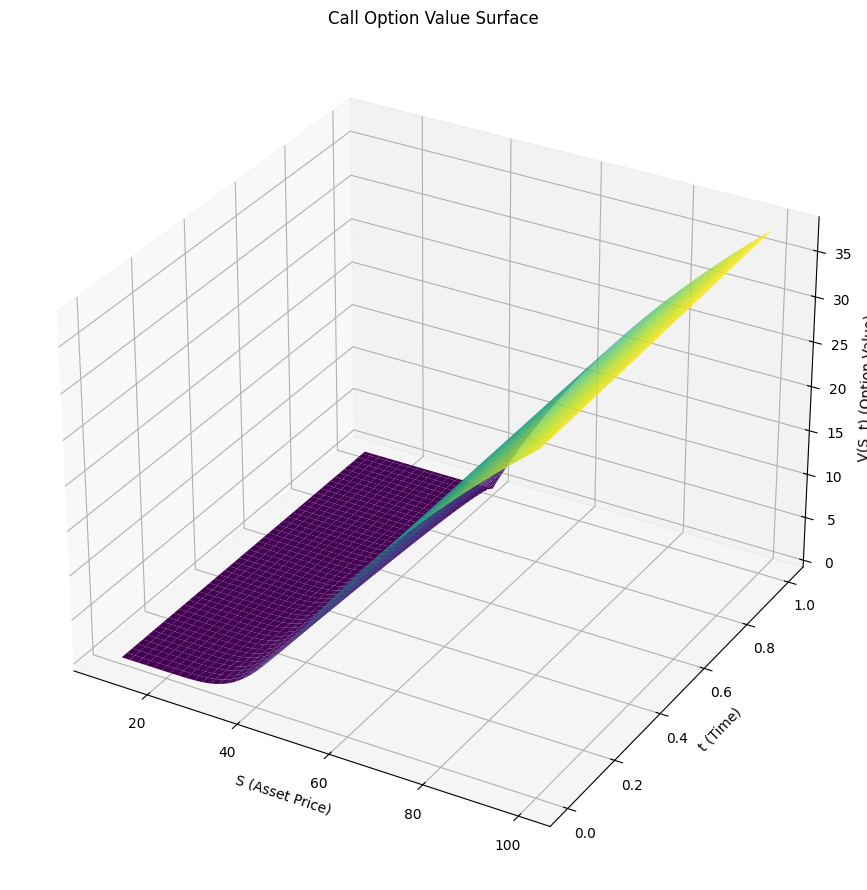

In [398]:
S_vals = np.linspace(10, 100, 100)
t_vals = np.linspace(0, T, 100)
S_grid, t_grid = np.meshgrid(S_vals, t_vals)
V_func = np.vectorize(V)
V_grid = V_func(S_grid, t_grid)

fig = plt.figure(figsize=(10, 9))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(S_grid, t_grid, V_grid, cmap='viridis')
ax.set_xlabel('S (Asset Price)')
ax.set_ylabel('t (Time)')
ax.set_zlabel('V(S, t) (Option Value)')
ax.set_title(f"{option_type.capitalize()} Option Value Surface")
plt.tight_layout()
plt.show()


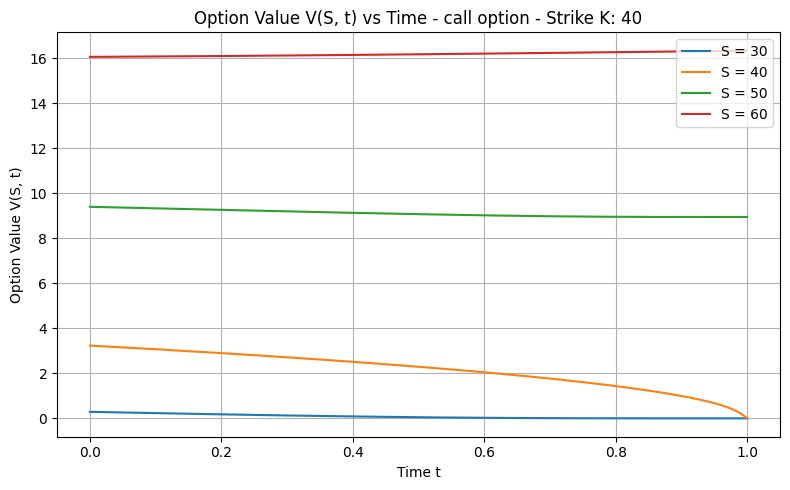

In [399]:
def plot_V_over_time(S_list):
    t_vals = np.linspace(0, T, 200)
    plt.figure(figsize=(8, 5))
    for S in S_list:
        values = [V(S, t) for t in t_vals]
        plt.plot(t_vals, values, label=f"S = {S}")
    plt.title(f"Option Value V(S, t) vs Time - {option_type} option - Strike K: {K}")
    plt.xlabel("Time t")
    plt.ylabel("Option Value V(S, t)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

plot_V_over_time([30, 40, 50, 60])
